# Seed별 Phase 2 학습 비교 분석
두 seed의 Phase 2 로그를 파싱해서 H_s, H_p, argmax, d_commit 등을 비교합니다.

In [4]:
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ===== 경로 설정 =====

#LOG_SEED_42 = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-EXP1_BASIC_NO_REG_VERSION/50/20260311_215828/train_log_20260311_215828.log"
#LOG_SEED_50 = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-EXP2_ROBUST_HIER_YES_REG_VERSION/50/20260311_220743/train_log_20260311_220743.log"
#LOG_SEED_42 = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-EXP3_NEW_REG_NORMAL_HIER_VERSION/50/20260311_221428/train_log_20260311_221428.log"
#LOG_SEED_42 = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-EXP5_NEW_REG_ANNEALING_HIER_VERSION/50/20260311_224828/train_log_20260311_224828.log"

#LOG_SEED_42 = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-EXP6_Entropy_REG_HIER_VERSION/50/20260312_141020/train_log_20260312_141020.log"
#LOG_SEED_50 = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-EXP4_NEW_REG_ROBUST_HIER_VERSION/50/20260311_221531/train_log_20260311_221531.log"
#LOG_SEED_42 = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-EXP4_NEW_REG_ROBUST_HIER_VERSION/42/20260312_162704/train_log_20260312_162704.log"

#LOG_SEED_42 = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-1_AY_SOFTTAU_005/42/20260313_132944/train_log_20260313_132944.log"
LOG_SEED_42 = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1.0_alpha-0.5_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-EXP3_reg_alpha05_fgwalpha1_HS1/50/20260325_234429/train_log_20260325_234429.log"
#LOG_SEED_50 = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-1_AY/42/20260313_131439/train_log_20260313_131439.log"
#LOG_SEED_50 = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-XTFORMER_EVALUATION100/50/20260225_221853/train_log_20260225_221853.log"
LOG_SEED_50 = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1.0_alpha-0.5_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-EXP3_reg_alpha05_fgwalpha1_HS1/50/20260325_234429/train_log_20260325_234429.log"

M = 8  # number of LCGs

In [5]:
def parse_log(filepath, M=8):
    """Phase 2 로그에서 routing/dcommit/auc 정보를 파싱"""
    data = defaultdict(list)
    
    # Regex patterns
    routing_pat = re.compile(
        r'\[ROUTING\] Step (\d+) \| Epoch (\d+) \|.*?'
        r'H_s=([\d.]+) H_p=([\d.]+) \|.*?'
        r'top1=([\d.]+)\(([\d.]+)~([\d.]+)\) \|.*?'
        r'p=\[([^\]]+)\] \|.*?'
        r'argmax=\[([^\]]+)\]'
    )
    
    dcommit_stats_pat = re.compile(
        r'd_commit: mean=([\d.]+), std=([\d.]+), min=([\d.]+), max=([\d.]+)'
    )
    gap_pat = re.compile(
        r'per-sample gap: mean=([\d.]+), min=([\d.]+), max=([\d.]+)'
    )
    logits_gap_pat = re.compile(
        r'logits gap: mean=([\d.]+), min=([\d.]+), max=([\d.]+)'
    )
    reg_pat = re.compile(
        r'\[REG\] LB=([\d.]+) \| Orth=([\d.]+) \| weighted_orth=([\d.]+) \| total_reg=([\d.]+)'
    )
    
    # AUC: 두 줄에 걸쳐 나옴
    pre_epoch_pat = re.compile(r'\[Pre\]\[Epoch (\d+)/\d+\]')
    auc_line_pat = re.compile(
        r'>>>\s+(Local|Global)\s*\([^)]*\):\s*Mean AUC ([\d.]+)\s*\|\s*Per-Source:\s*\[([^\]]+)\]'
    )
    
    feat_range_pat = re.compile(r'feat range: ([\d.]+)')
    mcost_range_pat = re.compile(r'M_cost range: ([\d.]+)')
    
    current_pre_epoch = None
    
    with open(filepath, 'r') as f:
        for line in f:
            # Routing
            m = routing_pat.search(line)
            if m:
                step = int(m.group(1))
                epoch = int(m.group(2))
                h_s = float(m.group(3))
                h_p = float(m.group(4))
                top1_mean = float(m.group(5))
                top1_min = float(m.group(6))
                top1_max = float(m.group(7))
                p_vals = [float(x) for x in m.group(8).split()]
                argmax_vals = [int(x) for x in m.group(9).split()]
                
                data['step'].append(step)
                data['epoch'].append(epoch)
                data['h_s'].append(h_s)
                data['h_p'].append(h_p)
                data['top1_mean'].append(top1_mean)
                data['top1_min'].append(top1_min)
                data['top1_max'].append(top1_max)
                data['p_vals'].append(p_vals)
                data['argmax'].append(argmax_vals)
                continue
            
            # D_commit stats
            m = dcommit_stats_pat.search(line)
            if m:
                data['dc_mean'].append(float(m.group(1)))
                data['dc_std'].append(float(m.group(2)))
                data['dc_min'].append(float(m.group(3)))
                data['dc_max'].append(float(m.group(4)))
                continue
            
            # Per-sample gap
            m = gap_pat.search(line)
            if m:
                data['gap_mean'].append(float(m.group(1)))
                continue
            
            # Logits gap
            m = logits_gap_pat.search(line)
            if m:
                data['logits_gap_mean'].append(float(m.group(1)))
                continue
            
            # REG
            m = reg_pat.search(line)
            if m:
                data['lb_loss'].append(float(m.group(1)))
                data['orth_loss'].append(float(m.group(2)))
                data['total_reg'].append(float(m.group(4)))
                continue
            
            # Pre Epoch 번호 추적
            m = pre_epoch_pat.search(line)
            if m:
                current_pre_epoch = int(m.group(1))
                continue
            
            # AUC 라인 (별도 줄)
            m = auc_line_pat.search(line)
            if m and current_pre_epoch is not None:
                branch = m.group(1).lower()
                mean_auc = float(m.group(2))
                per_source = [float(x.strip().strip("'")) for x in m.group(3).split(',')]
                data[f'auc_{branch}_epoch'].append(current_pre_epoch)
                data[f'auc_{branch}_mean'].append(mean_auc)
                data[f'auc_{branch}_per_source'].append(per_source)
                continue
            
            # Feat range
            m = feat_range_pat.search(line)
            if m:
                data['feat_range'].append(float(m.group(1)))
                continue
            
            # M_cost range
            m = mcost_range_pat.search(line)
            if m:
                data['mcost_range'].append(float(m.group(1)))
                continue
    
    return dict(data)

print("Parser defined.")

Parser defined.


In [6]:
# 파싱
d42 = parse_log(LOG_SEED_42, M)
d50 = parse_log(LOG_SEED_50, M)

print(f"Seed 42: {len(d42.get('step',[]))} routing entries, {len(d42.get('auc_global_epoch',[]))} AUC entries")
print(f"Seed 50: {len(d50.get('step',[]))} routing entries, {len(d50.get('auc_global_epoch',[]))} AUC entries")

Seed 42: 430 routing entries, 307 AUC entries
Seed 50: 430 routing entries, 307 AUC entries


In [7]:
def plot_comparison(d42, d50, key_y, ylabel, title, key_x=None, figsize=(12,4)):
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    if key_y in d42 and len(d42[key_y]) > 0:
        x42 = d42[key_x][:len(d42[key_y])] if key_x and key_x in d42 else range(len(d42[key_y]))
        ax.plot(x42, d42[key_y], label='Seed 42', alpha=0.8)
    
    if key_y in d50 and len(d50[key_y]) > 0:
        x50 = d50[key_x][:len(d50[key_y])] if key_x and key_x in d50 else range(len(d50[key_y]))
        ax.plot(x50, d50[key_y], label='Seed 50', alpha=0.8)
    
    ax.set_xlabel(key_x or 'Log Entry')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 1. H_s, H_p 비교 (Routing Entropy)

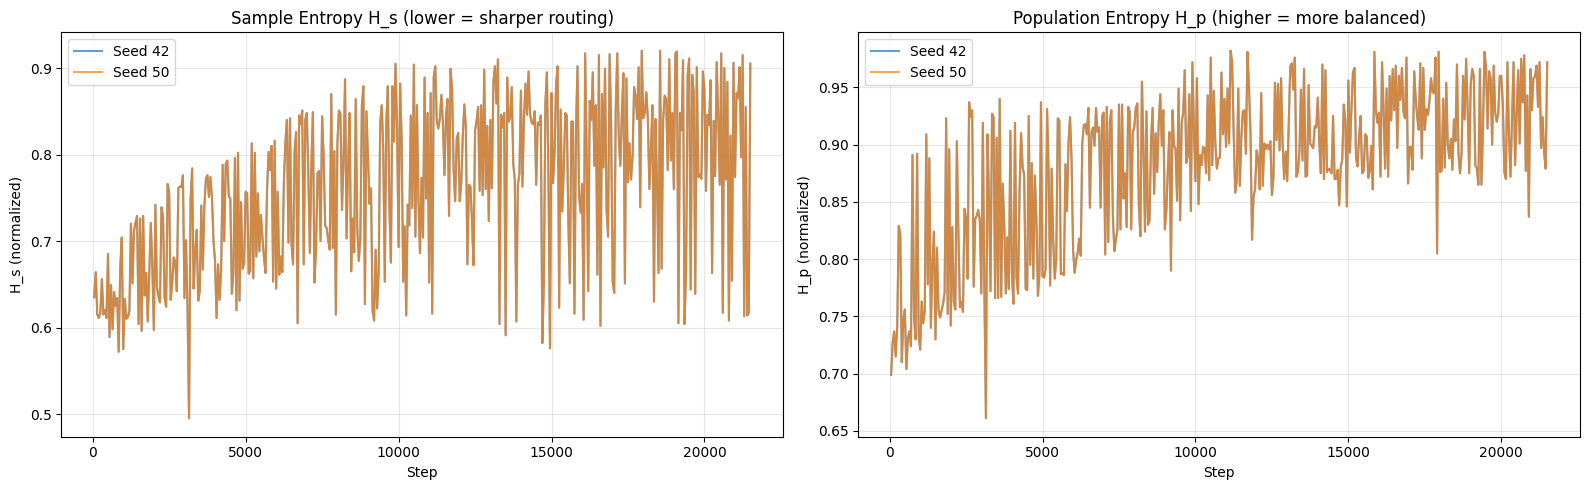

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# H_s (Sample entropy) - 낮을수록 sharp
if 'h_s' in d42: axes[0].plot(d42['step'], d42['h_s'], label='Seed 42', alpha=0.7)
if 'h_s' in d50: axes[0].plot(d50['step'], d50['h_s'], label='Seed 50', alpha=0.7)
axes[0].set_xlabel('Step'); axes[0].set_ylabel('H_s (normalized)')
axes[0].set_title('Sample Entropy H_s (lower = sharper routing)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# H_p (Population entropy) - 높을수록 balanced
if 'h_p' in d42: axes[1].plot(d42['step'], d42['h_p'], label='Seed 42', alpha=0.7)
if 'h_p' in d50: axes[1].plot(d50['step'], d50['h_p'], label='Seed 50', alpha=0.7)
axes[1].set_xlabel('Step'); axes[1].set_ylabel('H_p (normalized)')
axes[1].set_title('Population Entropy H_p (higher = more balanced)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Top1 Probability (Routing Sharpness)

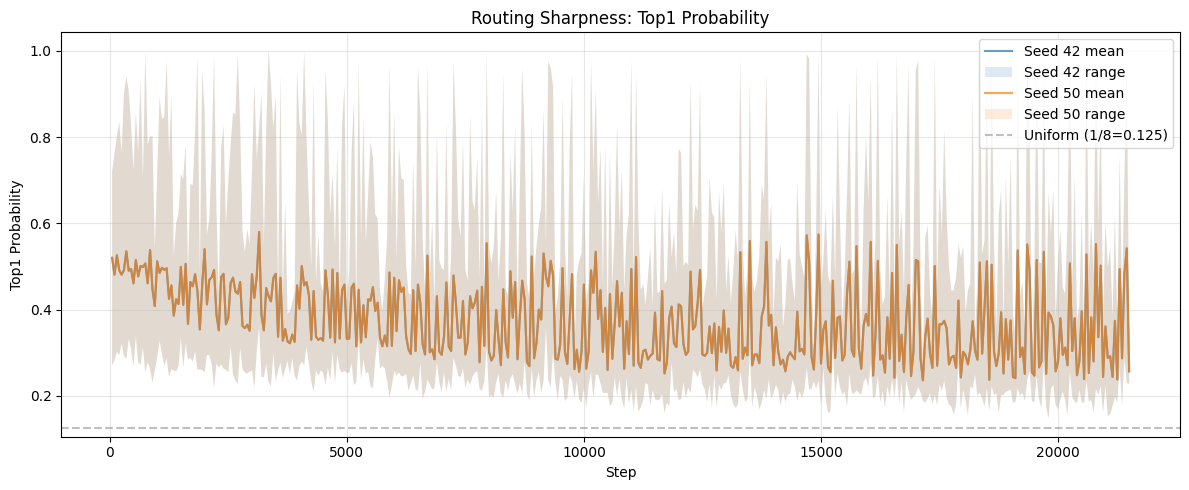

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

if 'top1_mean' in d42:
    ax.plot(d42['step'], d42['top1_mean'], label='Seed 42 mean', alpha=0.7)
    ax.fill_between(d42['step'], d42['top1_min'], d42['top1_max'], alpha=0.15, label='Seed 42 range')

if 'top1_mean' in d50:
    ax.plot(d50['step'], d50['top1_mean'], label='Seed 50 mean', alpha=0.7)
    ax.fill_between(d50['step'], d50['top1_min'], d50['top1_max'], alpha=0.15, label='Seed 50 range')

ax.axhline(y=1/M, color='gray', linestyle='--', alpha=0.5, label=f'Uniform (1/{M}={1/M:.3f})')
ax.set_xlabel('Step'); ax.set_ylabel('Top1 Probability')
ax.set_title('Routing Sharpness: Top1 Probability')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Per-LCG Argmax Count 추이 (LCG 활성도)

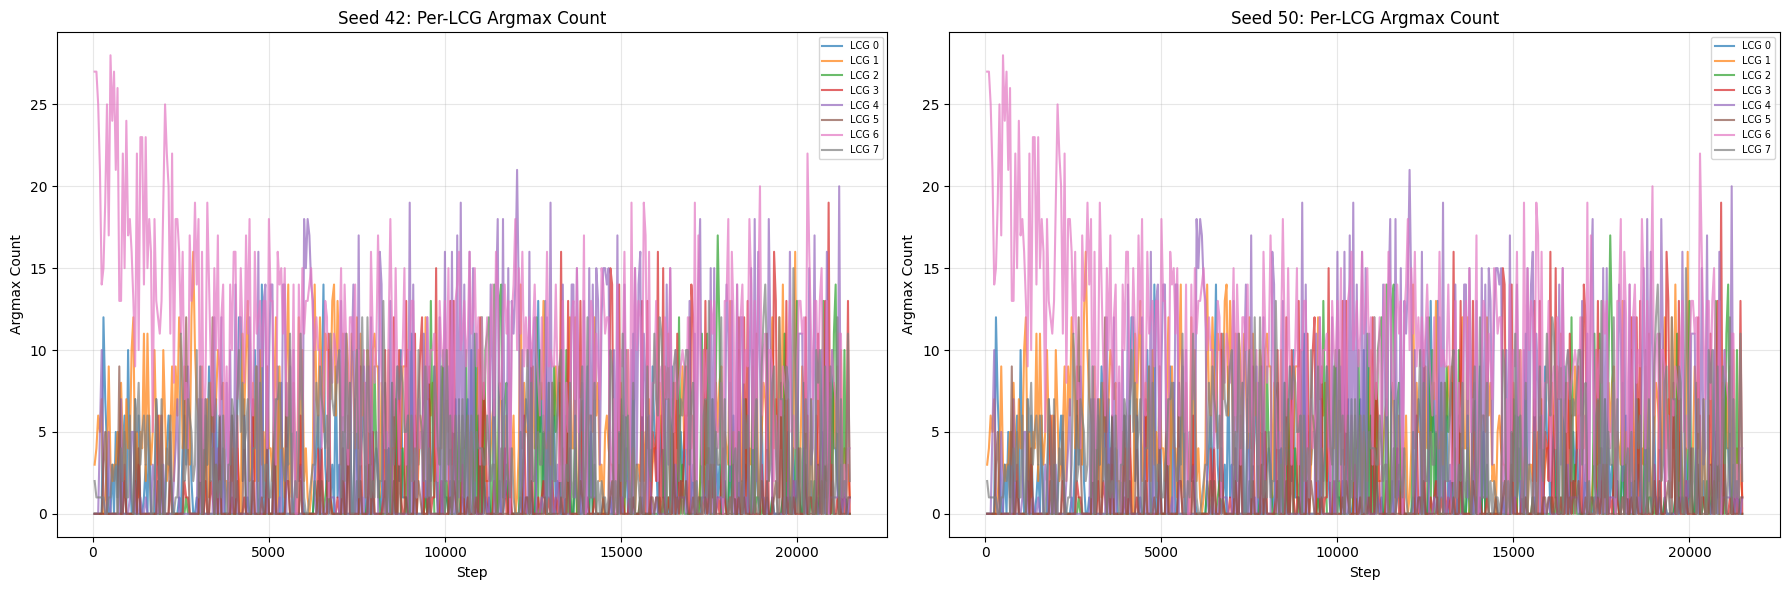

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for idx, (data, seed_name) in enumerate([(d42, 'Seed 42'), (d50, 'Seed 50')]):
    if 'argmax' not in data or len(data['argmax']) == 0:
        continue
    argmax_arr = np.array(data['argmax'])  # [num_steps, M]
    steps = data['step'][:len(argmax_arr)]
    
    for lcg_i in range(M):
        axes[idx].plot(steps, argmax_arr[:, lcg_i], label=f'LCG {lcg_i}', alpha=0.7)
    
    axes[idx].set_xlabel('Step'); axes[idx].set_ylabel('Argmax Count')
    axes[idx].set_title(f'{seed_name}: Per-LCG Argmax Count')
    axes[idx].legend(loc='upper right', fontsize=7)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Population Distribution (p) 추이

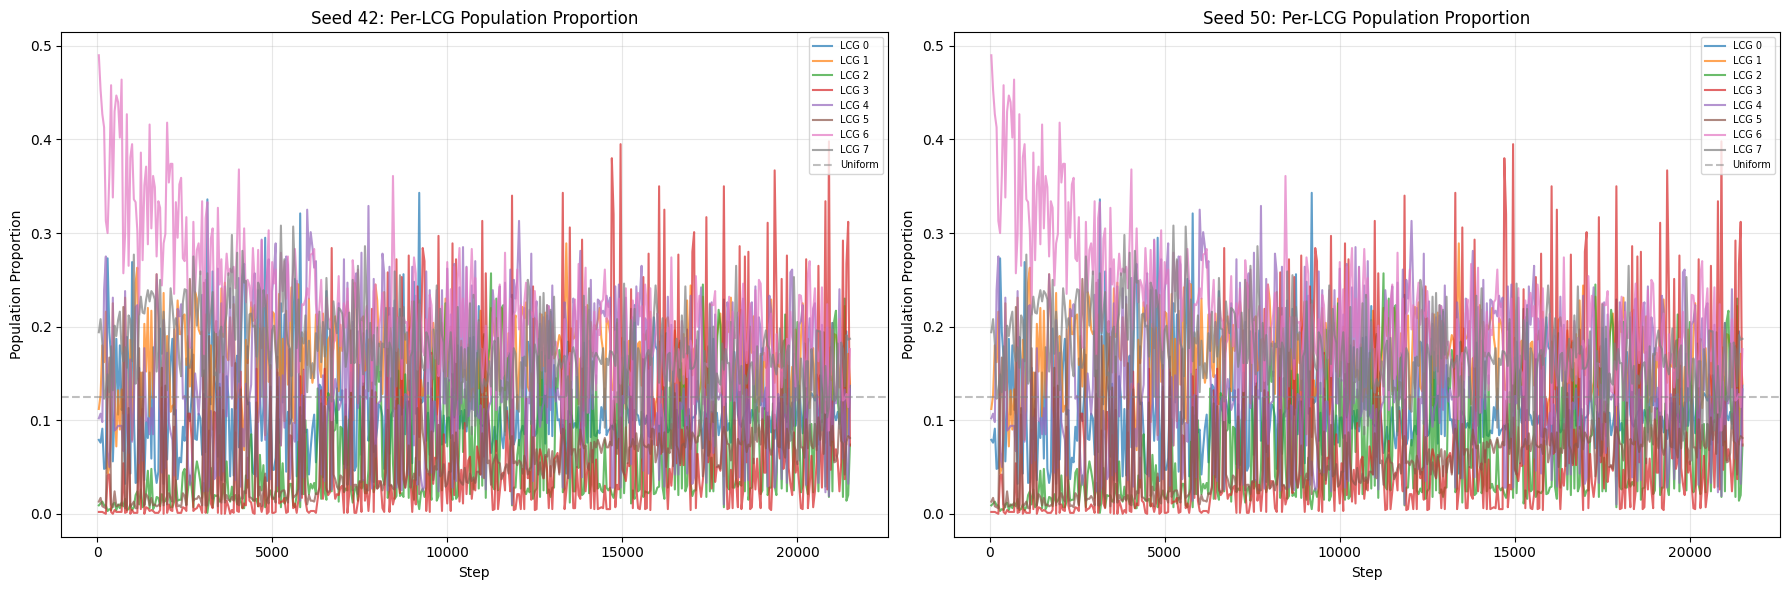

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for idx, (data, seed_name) in enumerate([(d42, 'Seed 42'), (d50, 'Seed 50')]):
    if 'p_vals' not in data or len(data['p_vals']) == 0:
        continue
    p_arr = np.array(data['p_vals'])  # [num_steps, M]
    steps = data['step'][:len(p_arr)]
    
    for lcg_i in range(M):
        axes[idx].plot(steps, p_arr[:, lcg_i], label=f'LCG {lcg_i}', alpha=0.7)
    
    axes[idx].axhline(y=1/M, color='gray', linestyle='--', alpha=0.5, label=f'Uniform')
    axes[idx].set_xlabel('Step'); axes[idx].set_ylabel('Population Proportion')
    axes[idx].set_title(f'{seed_name}: Per-LCG Population Proportion')
    axes[idx].legend(loc='upper right', fontsize=7)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. D_commit 통계 비교

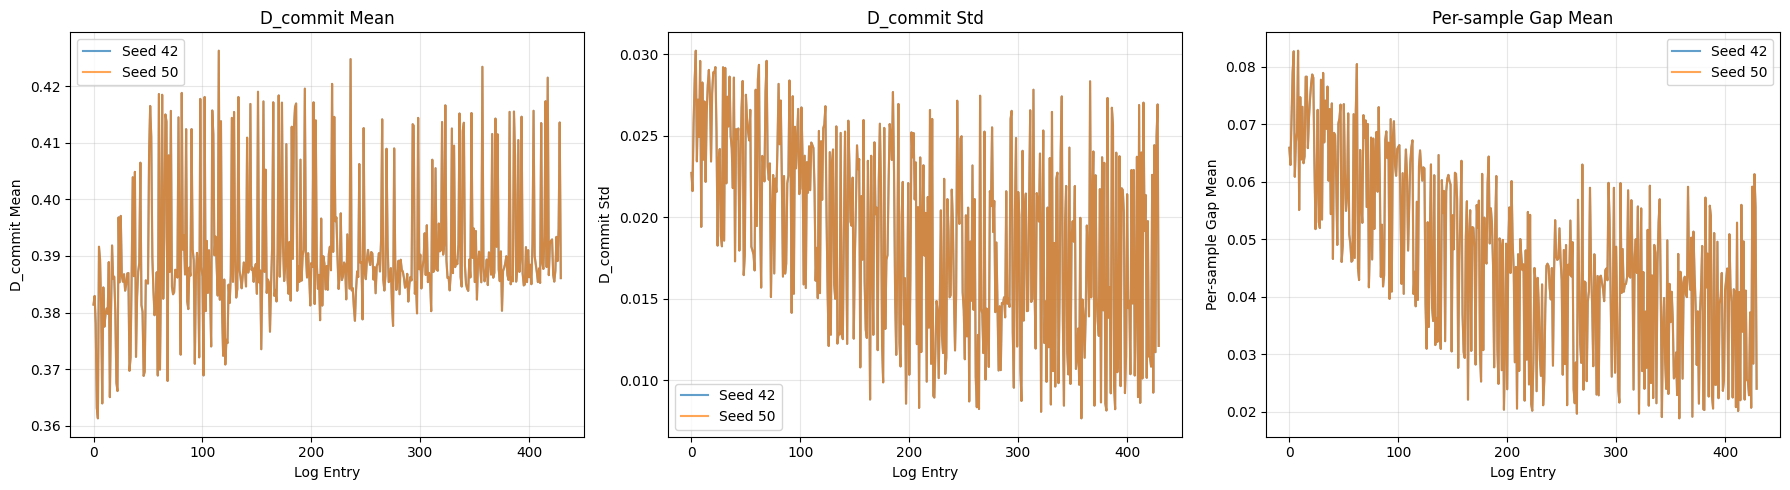

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# D_commit mean
plot_keys = [('dc_mean', 'D_commit Mean'), ('dc_std', 'D_commit Std'), ('gap_mean', 'Per-sample Gap Mean')]

for ax, (key, title) in zip(axes, plot_keys):
    if key in d42 and len(d42[key]) > 0:
        ax.plot(range(len(d42[key])), d42[key], label='Seed 42', alpha=0.7)
    if key in d50 and len(d50[key]) > 0:
        ax.plot(range(len(d50[key])), d50[key], label='Seed 50', alpha=0.7)
    ax.set_xlabel('Log Entry'); ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

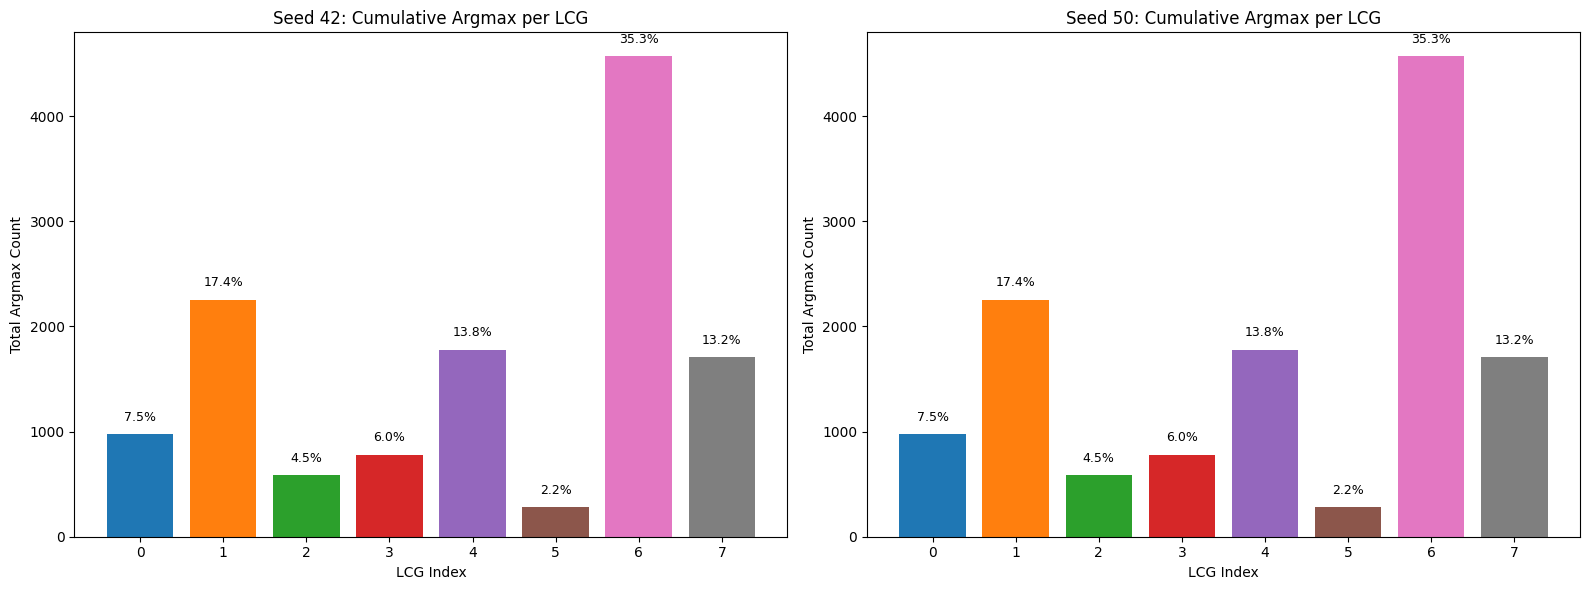

In [13]:
# 로그 파싱 후 추가할 셀

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (data, seed_name) in enumerate([(d42, 'Seed 42'), (d50, 'Seed 50')]):
    if 'argmax' not in data or len(data['argmax']) == 0:
        continue
    argmax_arr = np.array(data['argmax'])  # [num_steps, M]
    total_per_lcg = argmax_arr.sum(axis=0)
    
    M = len(total_per_lcg)
    colors = plt.cm.tab10(range(M))
    axes[idx].bar(range(M), total_per_lcg, color=colors)
    axes[idx].set_xlabel('LCG Index')
    axes[idx].set_ylabel('Total Argmax Count')
    axes[idx].set_title(f'{seed_name}: Cumulative Argmax per LCG')
    axes[idx].set_xticks(range(M))
    
    # 비율 표시
    total = total_per_lcg.sum()
    for i, v in enumerate(total_per_lcg):
        axes[idx].text(i, v + total*0.01, f'{v/total*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Logits Gap (routing 구별력)

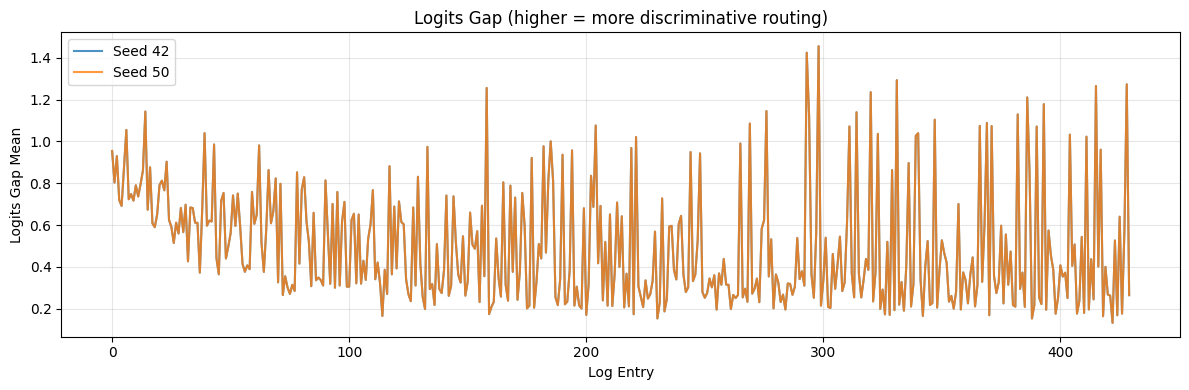

In [14]:
plot_comparison(d42, d50, 'logits_gap_mean', 'Logits Gap Mean', 
                'Logits Gap (higher = more discriminative routing)')

## 7. Regularization Loss 비교

/tmp/ipykernel_2361841/1571570332.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(); ax.grid(True, alpha=0.3)


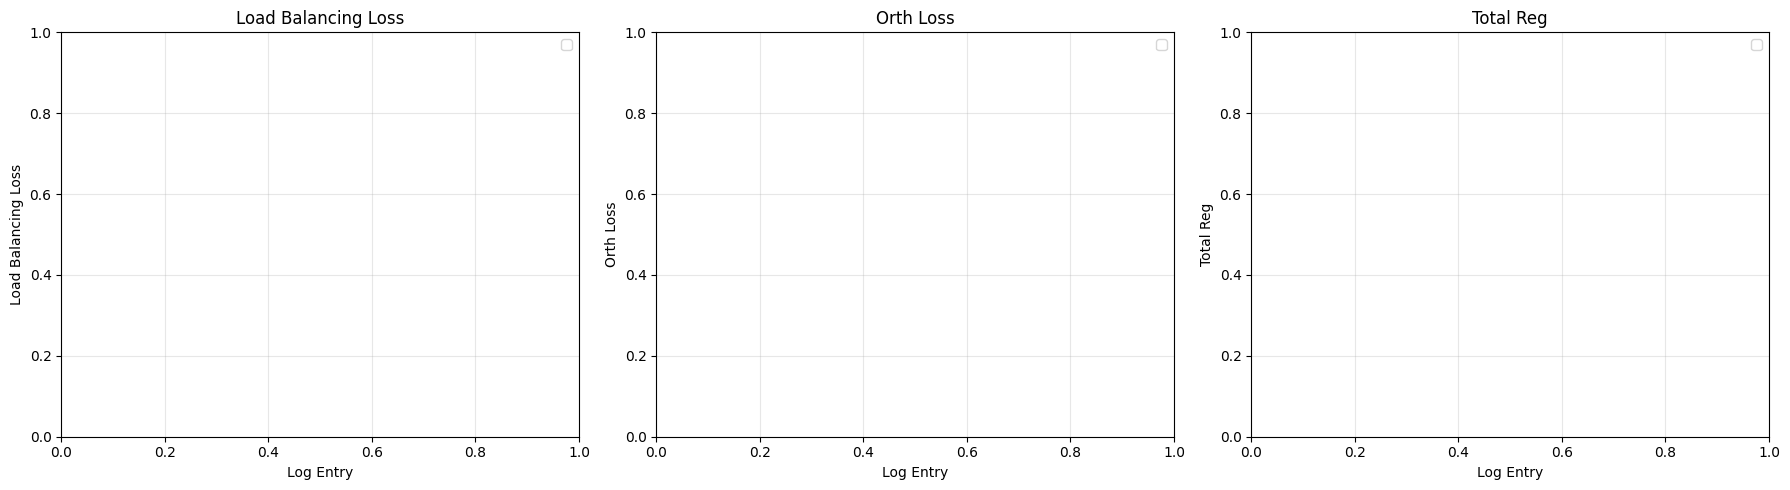

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (key, title) in zip(axes, [('lb_loss', 'Load Balancing Loss'), ('orth_loss', 'Orth Loss'), ('total_reg', 'Total Reg')]):
    if key in d42 and len(d42[key]) > 0:
        ax.plot(range(len(d42[key])), d42[key], label='Seed 42', alpha=0.7)
    if key in d50 and len(d50[key]) > 0:
        ax.plot(range(len(d50[key])), d50[key], label='Seed 50', alpha=0.7)
    ax.set_xlabel('Log Entry'); ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Source Val AUC 추이 (Global)

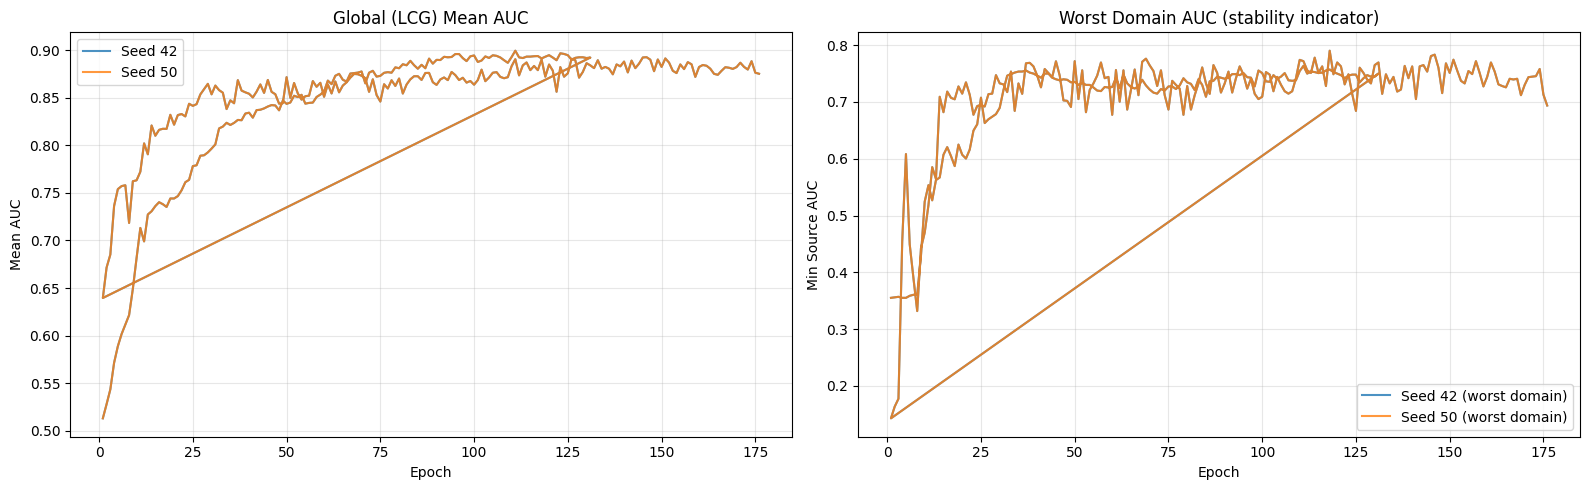

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Global Mean AUC
if 'auc_global_epoch' in d42 and len(d42['auc_global_mean']) > 0:
    axes[0].plot(d42['auc_global_epoch'], d42['auc_global_mean'], label='Seed 42', alpha=0.8)
if 'auc_global_epoch' in d50 and len(d50['auc_global_mean']) > 0:
    axes[0].plot(d50['auc_global_epoch'], d50['auc_global_mean'], label='Seed 50', alpha=0.8)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Mean AUC')
axes[0].set_title('Global (LCG) Mean AUC')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Per-source AUC for worst domain
for seed_data, seed_name in [(d42, 'Seed 42'), (d50, 'Seed 50')]:
    if 'auc_global_per_source' in seed_data and len(seed_data['auc_global_per_source']) > 0:
        per_src = np.array(seed_data['auc_global_per_source'])
        epochs = seed_data['auc_global_epoch'][:len(per_src)]
        min_auc = per_src.min(axis=1)
        axes[1].plot(epochs, min_auc, label=f'{seed_name} (worst domain)', alpha=0.8)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Min Source AUC')
axes[1].set_title('Worst Domain AUC (stability indicator)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Feat Range & M_cost Range (LCG 구별력)

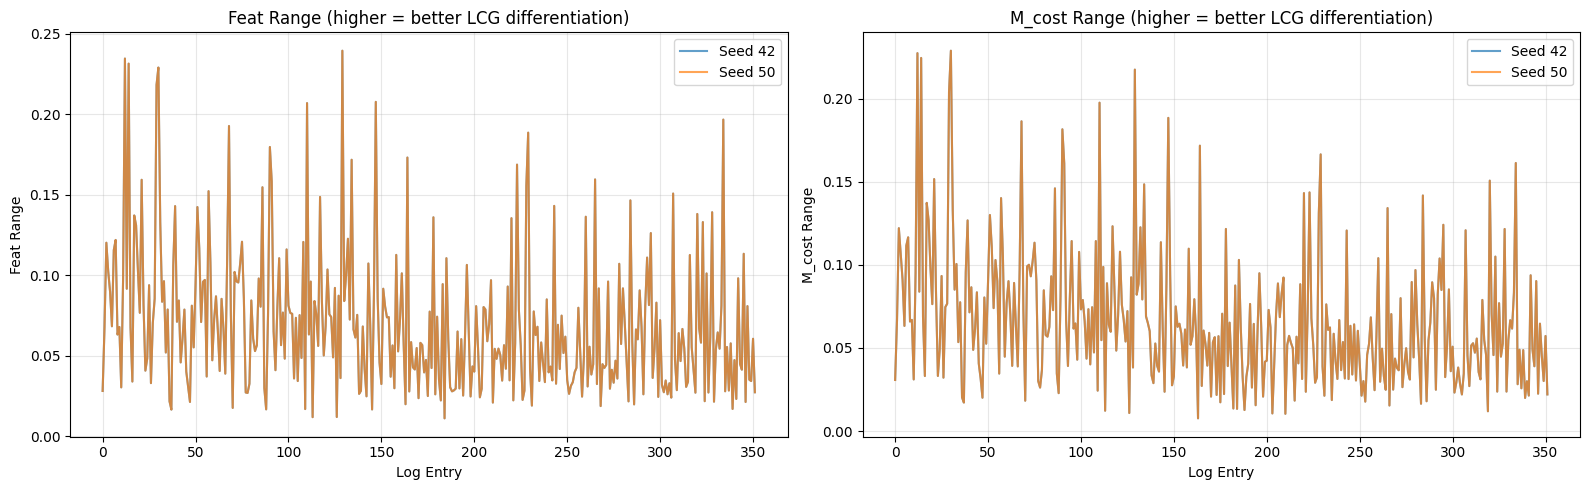

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (key, title) in zip(axes, [('feat_range', 'Feat Range'), ('mcost_range', 'M_cost Range')]):
    if key in d42 and len(d42[key]) > 0:
        ax.plot(range(len(d42[key])), d42[key], label='Seed 42', alpha=0.7)
    if key in d50 and len(d50[key]) > 0:
        ax.plot(range(len(d50[key])), d50[key], label='Seed 50', alpha=0.7)
    ax.set_xlabel('Log Entry'); ax.set_ylabel(title)
    ax.set_title(f'{title} (higher = better LCG differentiation)')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. 요약 통계

In [18]:
def summarize(data, name):
    print(f"\n{'='*50}")
    print(f"  {name} Summary")
    print(f"{'='*50}")
    
    if 'h_s' in data and len(data['h_s']) > 0:
        print(f"  H_s  : first={data['h_s'][0]:.3f}, last={data['h_s'][-1]:.3f}, min={min(data['h_s']):.3f}")
    if 'h_p' in data and len(data['h_p']) > 0:
        print(f"  H_p  : first={data['h_p'][0]:.3f}, last={data['h_p'][-1]:.3f}, max={max(data['h_p']):.3f}")
    if 'top1_mean' in data and len(data['top1_mean']) > 0:
        print(f"  Top1 : first={data['top1_mean'][0]:.3f}, last={data['top1_mean'][-1]:.3f}, max={max(data['top1_mean']):.3f}")
    if 'lb_loss' in data and len(data['lb_loss']) > 0:
        print(f"  LB   : first={data['lb_loss'][0]:.4f}, last={data['lb_loss'][-1]:.4f}")
    if 'gap_mean' in data and len(data['gap_mean']) > 0:
        print(f"  Gap  : first={data['gap_mean'][0]:.6f}, last={data['gap_mean'][-1]:.6f}")
    if 'logits_gap_mean' in data and len(data['logits_gap_mean']) > 0:
        print(f"  Logit: first={data['logits_gap_mean'][0]:.4f}, last={data['logits_gap_mean'][-1]:.4f}")
    if 'feat_range' in data and len(data['feat_range']) > 0:
        print(f"  FeatR: first={data['feat_range'][0]:.6f}, last={data['feat_range'][-1]:.6f}")
    if 'auc_global_mean' in data and len(data['auc_global_mean']) > 0:
        print(f"  AUC  : first={data['auc_global_mean'][0]:.4f}, best={max(data['auc_global_mean']):.4f}, last={data['auc_global_mean'][-1]:.4f}")
    
    # Dead LCG 분석 (마지막 10개 routing의 argmax)
    if 'argmax' in data and len(data['argmax']) >= 10:
        last_argmax = np.array(data['argmax'][-10:])
        total_per_lcg = last_argmax.sum(axis=0)
        dead = [i for i in range(len(total_per_lcg)) if total_per_lcg[i] == 0]
        print(f"  Dead LCGs (last 10 steps): {dead if dead else 'None'}")
        print(f"  LCG usage (last 10): {total_per_lcg}")

summarize(d42, 'Seed 42')
summarize(d50, 'Seed 50')


  Seed 42 Summary
  H_s  : first=0.635, last=0.905, min=0.495
  H_p  : first=0.699, last=0.972, max=0.982
  Top1 : first=0.520, last=0.257, max=0.580
  Gap  : first=0.065927, last=0.024010
  Logit: first=0.9539, last=0.2647
  FeatR: first=0.028150, last=0.027343
  AUC  : first=0.5132, best=0.8993, last=0.8751
  Dead LCGs (last 10 steps): None
  LCG usage (last 10): [13 41 40 18 27  3 55 38]

  Seed 50 Summary
  H_s  : first=0.635, last=0.905, min=0.495
  H_p  : first=0.699, last=0.972, max=0.982
  Top1 : first=0.520, last=0.257, max=0.580
  Gap  : first=0.065927, last=0.024010
  Logit: first=0.9539, last=0.2647
  FeatR: first=0.028150, last=0.027343
  AUC  : first=0.5132, best=0.8993, last=0.8751
  Dead LCGs (last 10 steps): None
  LCG usage (last 10): [13 41 40 18 27  3 55 38]
